In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/train_clean.csv")
sensor_cols = [col for col in df.columns if "sensor" in col]

print("Dataset shape:", df.shape)

Dataset shape: (20631, 27)


In [ ]:
# finding out the constant sensors..
sensor_variance = df[sensor_cols].var()

constant_sensors = sensor_variance[sensor_variance == 0].index.tolist()
print("sensor variance: ", sensor_variance)
print("Constant sensors:", constant_sensors)

# constant sensors...  Constant sensors: ['sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']

sensor variance:  sensor_1     0.000000e+00
sensor_2     2.500533e-01
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_7     7.833883e-01
sensor_8     5.038938e-03
sensor_9     4.876536e+02
sensor_10    0.000000e+00
sensor_11    7.133568e-02
sensor_12    5.439850e-01
sensor_13    5.172330e-03
sensor_14    3.639005e+02
sensor_15    1.406628e-03
sensor_16    1.203765e-35
sensor_17    2.398667e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    3.266927e-02
sensor_21    1.171825e-02
dtype: float64
Constant sensors: ['sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']


In [34]:
# removing the constant sensors
df = df.drop(columns=constant_sensors)

sensor_cols = [col for col in df.columns if "sensor" in col]

In [35]:
sensor_variance.sort_values().head(-5)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
dtype: float64

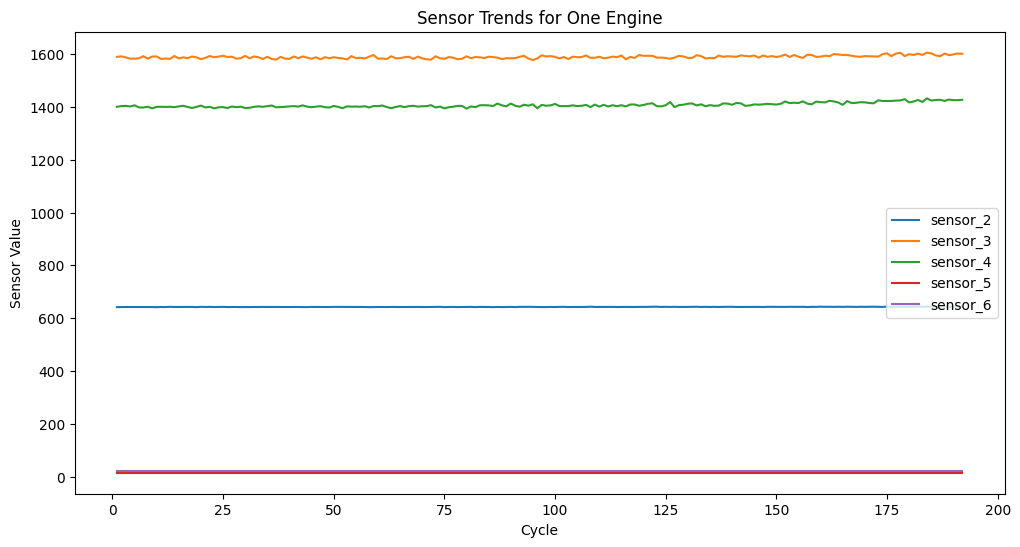

In [36]:
engine_id = 1
engine_df = df[df.engine_id == engine_id]

plt.figure(figsize=(12,6))

for s in sensor_cols[:5]:
    plt.plot(engine_df["cycle"], engine_df[s], label=s)

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor Trends for One Engine")
plt.show()

In [37]:
# averaging the sensor values per cycle
avg_trend = df.groupby("cycle")[sensor_cols].mean()

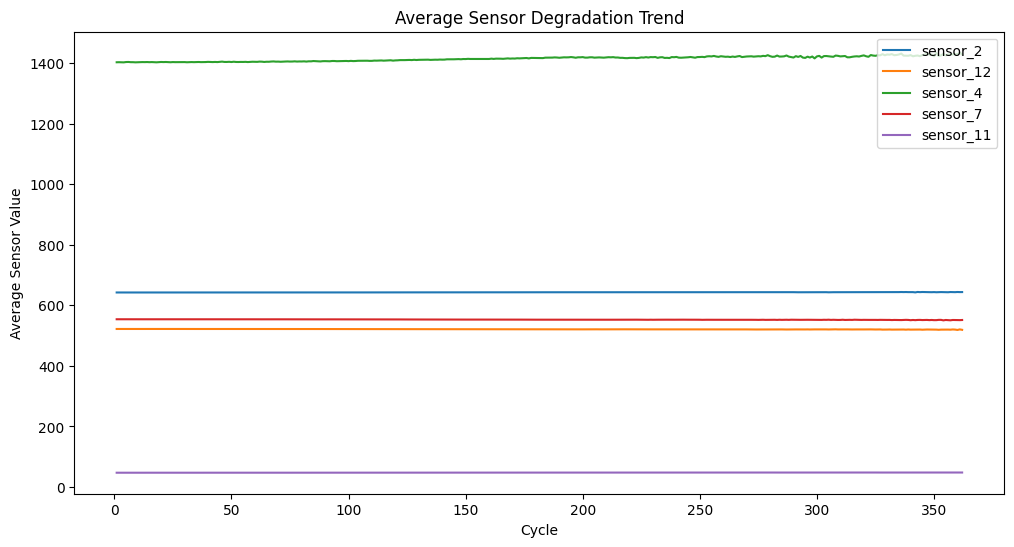

In [38]:

plt.figure(figsize=(12,6))

# for s in sensor_cols[:5]:
for s in ["sensor_2", "sensor_12", "sensor_4", "sensor_7", "sensor_11"]:
    plt.plot(avg_trend.index, avg_trend[s], label=s)

plt.legend()
plt.xlabel("Cycle")
plt.ylabel("Average Sensor Value")
plt.title("Average Sensor Degradation Trend")
plt.show()

In [39]:
# normalising features:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

In [40]:
df.to_csv("../data/processed/train_scaled.csv", index=False)

print("Saved scaled dataset")

Saved scaled dataset
